# Maximum Bond Dimension of 2D Square (Snake Ordering) for given $g/J$ and System Size
Here I provide the functions `generate_plots_square(g_array, side_sizes)` which return the maximum bond dimension required to compute the ground state for input $g$ (representing the ratio $g/J$ where $J$ is fixed at $1.0$ in this code) and for input square side length $L$.

In [34]:
import tenpy
from tenpy.models.tf_ising import TFIModel # 1D case uses TFIChain
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg

import matplotlib.pyplot as plt

The function `find_chi(g, Lx, Ly, chi_cap, max_sweeps)` returns the maximum bond dimension required to compute the ground state of the TF Ising model for given
- model parameter `g`,
- system dimensions `Lx` and `Ly`,
- bond dimension cap `chi_cap`, and
- maximum number of sweeps `max_sweeps`.

Note the following fixed parameters:
- algorithm is initialised with a product state (which has zero entanglement, ie $\chi_{\text{max}}=1$) given by $\ket\uparrow^{\otimes L}$
- `J=1.0` so the value of `g` can be interpreted as the ratio $g/J$
- `max_E_err` stops the ground state search when the maximum energy decrease between sweeps is `1e-10`
- `svd_min` truncates singular values below `1e-10`

In [35]:
def find_chi(g, Lx, Ly, chi_cap, max_sweeps=10):
    model_params = dict(
        lattice = 'Square',  # 1D case did not require specification of lattice type
        Lx = Lx,             # specifying L = int is sufficient for 1D case, but here length of both sides is needed
        Ly = Ly,
        J  = 1.0,
        g  = g,
        order = 'snake',
        bc_x = 'open',       # open here means no coupling / interaction between the edges of the square
        bc_y = 'open',
        bc_MPS = 'finite',   # bond dim at ends is 1
        conserve = None
    )
    model = TFIModel(model_params)

    N = Lx * Ly
    product_state = ["up"] * N      
    psi = MPS.from_product_state(
        model.lat.mps_sites(),
        product_state,
        bc='finite',
        unit_cell_width=1
    )

    dmrg_params = dict(
        mixer=True,              # adds some controlled randomness to escape bad minima, converge reliably
        max_sweeps=max_sweeps,   # at most 10 back-and-forth passes
        max_E_err=1e-10,         # stop when energy change between sweeps is this small
        trunc_params=dict(       # how to truncate when performing SVD and changing sites
            chi_max=chi_cap,     # maximum allowed bond dimension, ie loosely, maximum allowed entanglement
            svd_min=1e-10        # truncate singular values (diag values in S matrix) below this value
        ),
    )
    
    info = dmrg.run(psi, model, dmrg_params) # run DMRG
    return max(psi.chi)

The function `generate_plots_square(g_array, L_array)` takes in two arrays, one of values of `g` (ie the parameter ratio $g/J$) and another of the system sizes to be tested. It then plots all the graphs and of $g/J$ vs $L$ and returns a 2D array / matrix of required bond dimension for a given `g` and `L`.

In [44]:
def generate_plots_square(g_array, L_array, chi_cap=1024):
    chi_grid = []

    for g in g_array:
        row = []
        for L in L_array:
            chi = find_chi(g, L, L, chi_cap)
            row.append(chi)
        
        chi_grid.append(row)
        plt.plot(L_array, row, marker='o', markersize=4,label=f"g/J = {g}")

    plt.xlabel(r"Side length of square $L$")
    plt.ylabel(r"Max bond dimension $\chi_{\max}$")
    plt.legend()
    plt.grid(True)
    plt.show()

    return chi_grid

Now, we can input the parameter ratios $g/J$ and the system sizes that we want tested:

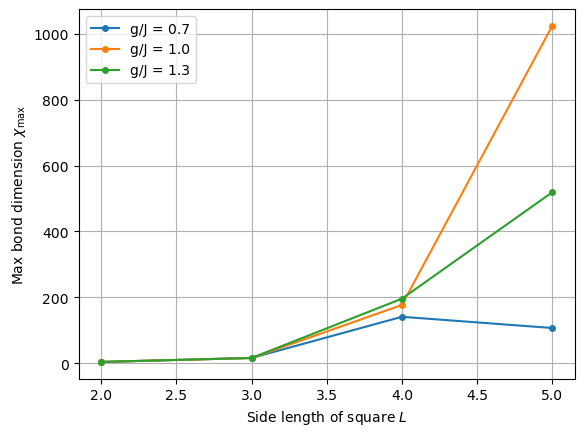

[[4, 16, 141, 107], [4, 16, 177, 1024], [4, 16, 196, 519]]

In [45]:
L_array = [2, 3, 4, 5]
g_array = [0.7, 1.0, 1.3]

generate_plots_square(g_array, L_array)